In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import Library yang dibutuhkan**

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

**Lokasi path yang di google drive**

In [3]:
file_path = '/content/drive/MyDrive/Praktikum Mandiri_ML/Praktikum6/data/heart.csv'

**Baca Dataset**

In [4]:
df = pd.read_csv(file_path)
print("=== 5 Data Teratas ===")
print(df.head())

=== 5 Data Teratas ===
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


**Info singkat Dataset**

In [5]:
print("\n=== Informasi Dataset ===")
print(df.info())


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


**Cek apakah nilai sudah kosong?**

In [6]:
print("\n=== Nilai Kosong ===")
print(df.isnull().sum())


=== Nilai Kosong ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


**Pisahkan fitur (x) dan Target (y)**

In [7]:
X = df.drop('target', axis=1)
y = df['target']

**Bagi data menjadi train (80%) dan test (20%)**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Standarisasi fitur**

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Buat model SVM dengan kernel RBF**

In [10]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

SVC(random_state=42)

**Prediksi data uji**

In [11]:
y_pred = svm_model.predict(X_test)

**Evaluasi Hasil**

In [12]:
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Akurasi Model ===")
print(f"{accuracy_score(y_test, y_pred) * 100:.2f}%")


=== Confusion Matrix ===
[[85 17]
 [ 6 97]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205


=== Akurasi Model ===
88.78%


**Visualisasi Confusion Matrix**

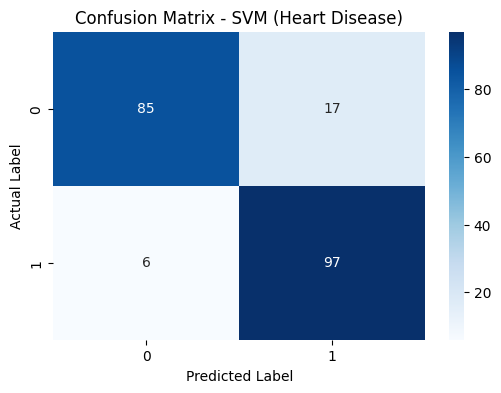

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM (Heart Disease)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

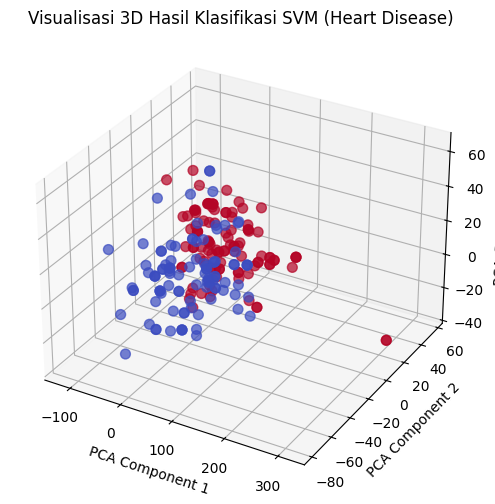

In [14]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# Kita ambil 3 komponen utama dengan PCA (untuk 3D visualization)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Split ulang data PCA untuk visualisasi
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Latih ulang SVM untuk data yang sudah direduksi menjadi 3 dimensi
svm_3d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_3d.fit(X_train_pca, y_train_pca)

# Prediksi untuk data test
y_pred_3d = svm_3d.predict(X_test_pca)

# Buat figure 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot berdasarkan label prediksi
ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], X_test_pca[:, 2],
           c=y_pred_3d, cmap='coolwarm', s=50, alpha=0.7)

# Label sumbu
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('Visualisasi 3D Hasil Klasifikasi SVM (Heart Disease)')

plt.show()
